C:\Users\Alicja\AppData\Local\Temp\ipykernel_16328\821111397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


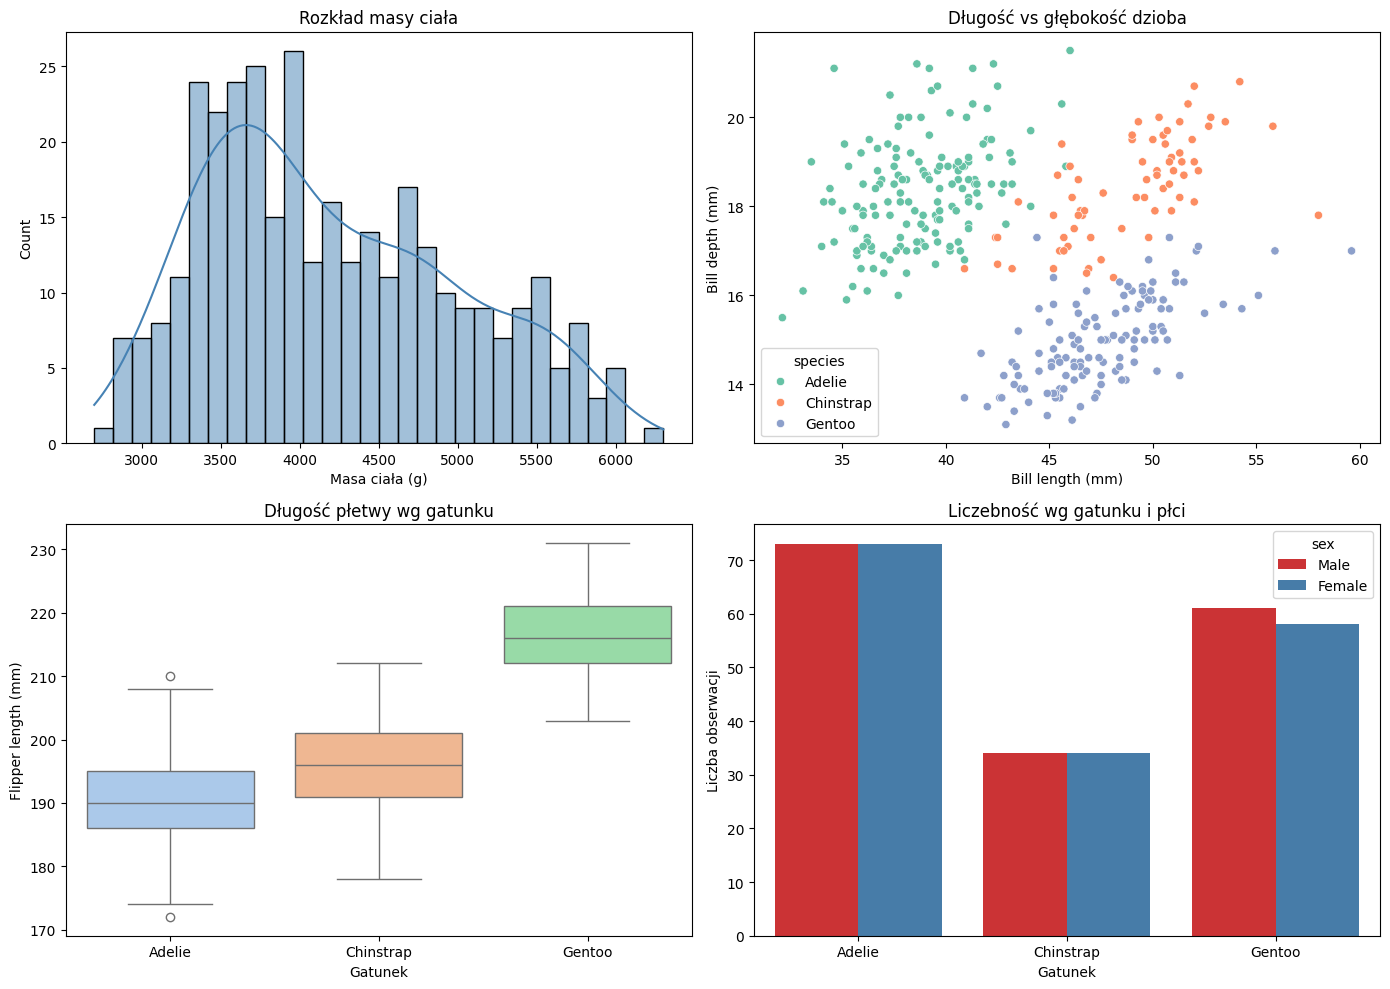

In [ ]:
# Stwórz kompletny dashboard EDA dla datasetu Penguins z 4 wykresami:
# Rozkład masy ciała (histogram z KDE)
# Scatter: bill_length vs bill_depth z kolorowaniem według gatunku
# Box plot: flipper_length według gatunku
# Bar plot: liczebność według gatunku i płci
# Dataset: penguins = sns.load_dataset('penguins')

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

penguins = sns.load_dataset('penguins')

# Utworzenie dashboardu
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Histogram
sns.histplot(
    data=penguins,
    x='body_mass_g', #masa ciała
    kde=True, #kształt danych, KDE - wygładza dane
    ax=axes[0, 0], #położenie wykresu
    bins=30, #30 przedziałów
    color='steelblue'
)

axes[0, 0].set_title('Rozkład masy ciała') # odwołanie do wykresu i nazwa wykresu
axes[0, 0].set_xlabel('Masa ciała (g)')

# Scatter: bill_length vs bill_depth z kolorowaniem według gatunku
sns.scatterplot(
    data=penguins,
    x='bill_length_mm', #długość dzioba
    y='bill_depth_mm', #głębokość dzioba
    hue='species', #kolor punktów, w zależności od gatunku
    palette='Set2', #umiejscowienie wykresu
    ax=axes[0, 1],
)

axes[0, 1].set_title('Długość vs głębokość dzioba')
axes[0, 1].set_xlabel('Bill length (mm)')
axes[0, 1].set_ylabel('Bill depth (mm)')

# Box plot: flipper_length według gatunku
sns.boxplot(
    data=penguins,
    x='species',
    y='flipper_length_mm',
    palette='pastel',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Długość płetwy wg gatunku')
axes[1, 0].set_xlabel('Gatunek')
axes[1, 0].set_ylabel('Flipper length (mm)')

# Bar plot: liczebność według gatunku i płci
sns.countplot(
    data=penguins,
    x='species', #gatunek
    hue='sex',
    palette='Set1',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Liczebność wg gatunku i płci')
axes[1, 1].set_xlabel('Gatunek')
axes[1, 1].set_ylabel('Liczba obserwacji')

plt.tight_layout()
plt.show()

In [19]:
# Utwórz wykres ceny akcji w czasie z:
# Główną linią ceny
# Średnią kroczącą 7-dniową (MA7)
# Średnią kroczącą 21-dniową (MA21)
# Zacienionym obszarem między MA7 a MA21
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=100)
price = 100 + np.cumsum(np.random.randn(100)) #losuje 100 wartości
df = pd.DataFrame({'date': dates, 'price': price})

df['volume'] = np.random.randint(100000, 500000, size=100) #tworzy sztuczny volume
df['returns'] = df['price'].pct_change() * 100 #procentowa zmiana ceny między dniami

# średnie kroczące
df['MA7'] = df['price'].rolling(window=7).mean()
df['MA21'] = df['price'].rolling(window=21).mean()


fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True, #wszystkie wykresy mają wspólną oś
    vertical_spacing=0.05, #odstęp między wykresami
    row_heights=[0.5, 0.25, 0.25],
    subplot_titles=('Cena akcji', 'Wolumen', 'Dzienne stopy zwrotu (%)')
)

# Główna linia ceny
fig.add_trace(
    go.Scatter(x=dates, y=price, mode='lines',
    name='Cena', line=dict(color='blue', width=2),
    fill='tozeroy', fillcolor='rgba(0,100,255,0.1)'),
    row=1, col=1
)

# Średnią kroczącą 7-dniową (MA7)
fig.add_trace(
    go.Scatter(
        x=df['date'],
        y=df['MA7'],
        mode='lines',
        name='MA7',
        line=dict(color='blue', width=1.5)
    ),
    row=1,
    col=1
)
# Średnią kroczącą 21-dniową (MA21)
fig.add_trace(
    go.Scatter(
        x=df['date'],
        y=df['MA21'],
        mode='lines',
        name='MA21',
        line=dict(color='orange', width=1.5),
        fill='tonexty', # Zacienionym obszarem między MA7 a MA21 // cieniuje obszar między aktualną linią a poprzednią linią.
        fillcolor='rgba(0,200,0,0.2)'
    ),
    row=1,
    col=1
)

